🔄 데이터 로드 중...
🔄 위성 데이터 인덱싱 중...


Indexing:   0%|          | 0/19956 [00:00<?, ?it/s]

🔄 매칭 분석 시작...


Matching:   0%|          | 0/9319 [00:00<?, ?it/s]


📊 [매칭 분석 결과]
총 매칭 성공 샘플: 9319개
평균 오차: 203.80일
중위 오차: 4.00일
------------------------------
✅ 허용 오차(15일) 이내 데이터: 5793개
✅ 유효 비율: 62.16%


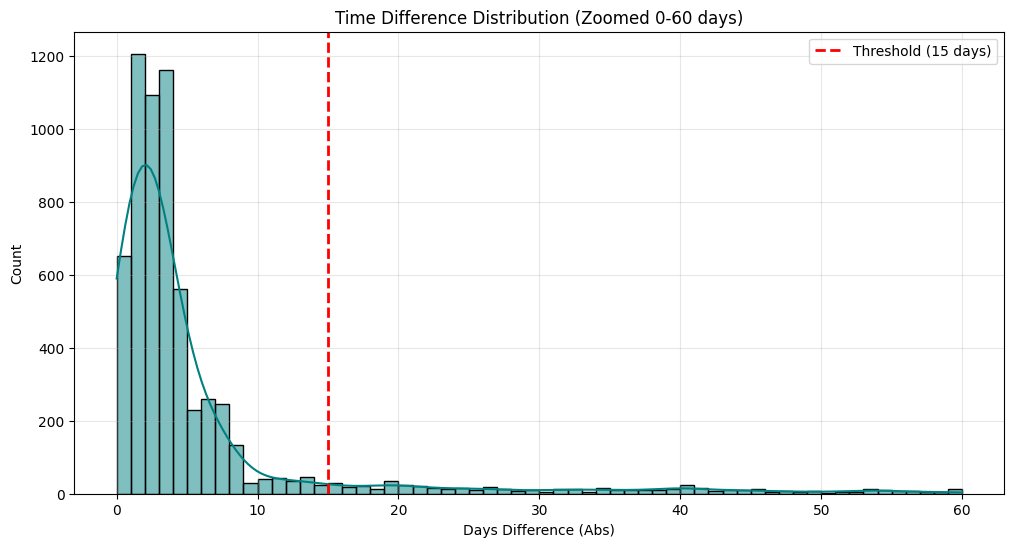

In [2]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# ==========================================
# 1. 설정 및 데이터 로드
# ==========================================
BASE_DIR = ".."
CSV_PATH = os.path.join(BASE_DIR, 'rawData', 'water_quality_training_dataset.csv')
CHIP_DIR = os.path.join(BASE_DIR, 'rawData', 'chips')

# 시각화 및 검증 기준 설정
PLOT_LIMIT = 60         # 그래프 X축 범위 (일)
VALID_THRESHOLD = 15    # 유효 데이터 허용 오차 (일)

print("🔄 데이터 로드 중...")
try:
    water_df = pd.read_csv(CSV_PATH)
    # 날짜 포맷 강제 지정 (dayfirst=True)
    water_df['Sample Date'] = pd.to_datetime(water_df['Sample Date'], dayfirst=True, format='mixed')
except Exception as e:
    print(f"❌ 데이터 로드 실패: {e}")
    raise

# ==========================================
# 2. 위성 칩 인덱싱 (고속화)
# ==========================================
print("🔄 위성 데이터 인덱싱 중...")
chip_files = glob.glob(f"{CHIP_DIR}/loc_*/*.npy")
chip_data = []

for f in tqdm(chip_files, desc="Indexing"):
    try:
        parts = f.split(os.sep)
        loc_id = parts[-2].replace('loc_', '')
        date_str = parts[-1].replace('.npy', '')
        chip_data.append({'loc_id': loc_id, 'chip_date': pd.to_datetime(date_str)})
    except:
        continue

chip_df = pd.DataFrame(chip_data)

# ==========================================
# 3. 최단 거리 매칭 (Nearest Matching)
# ==========================================
print("🔄 매칭 분석 시작...")
water_df['loc_id'] = water_df.apply(lambda x: f"{x['Latitude']:.4f}_{x['Longitude']:.4f}", axis=1)

diff_list = []

for idx, row in tqdm(water_df.iterrows(), total=len(water_df), desc="Matching"):
    loc = row['loc_id']
    target_date = row['Sample Date']
    
    # 해당 지역 칩 필터링
    candidates = chip_df[chip_df['loc_id'] == loc]
    
    if not candidates.empty:
        # 날짜 차이 절댓값 계산
        min_diff = (candidates['chip_date'] - target_date).abs().min()
        diff_list.append(min_diff.days)

res_df = pd.DataFrame(diff_list, columns=['diff_days'])

# ==========================================
# 4. 결과 분석 및 시각화
# ==========================================
total_matched = len(res_df)
valid_count = len(res_df[res_df['diff_days'] <= VALID_THRESHOLD])
ratio = (valid_count / total_matched) * 100

print("\n" + "="*40)
print(f"📊 [매칭 분석 결과]")
print("="*40)
print(f"총 매칭 성공 샘플: {total_matched}개")
print(f"평균 오차: {res_df['diff_days'].mean():.2f}일")
print(f"중위 오차: {res_df['diff_days'].median():.2f}일")
print("-" * 30)
print(f"✅ 허용 오차({VALID_THRESHOLD}일) 이내 데이터: {valid_count}개")
print(f"✅ 유효 비율: {ratio:.2f}%")
print("="*40)

# 시각화 (PLOT_LIMIT 적용)
plt.figure(figsize=(12, 6))
filtered_data = res_df[res_df['diff_days'] <= PLOT_LIMIT]

sns.histplot(filtered_data['diff_days'], bins=PLOT_LIMIT, kde=True, color='teal')
plt.axvline(VALID_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({VALID_THRESHOLD} days)')

plt.title(f'Time Difference Distribution (Zoomed 0-{PLOT_LIMIT} days)')
plt.xlabel('Days Difference (Abs)')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()